In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


train accuracy= 97.653%
test accuracy= 95.105%


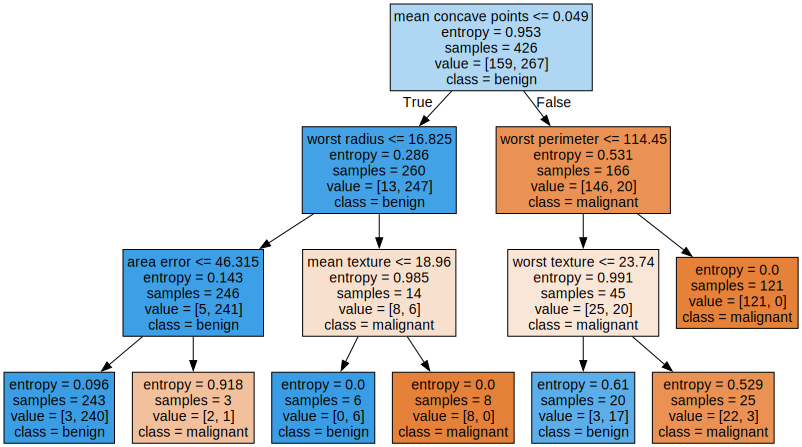

In [6]:
# START_CODE 
clf = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,
    max_depth=3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

graph_viz = tree.export_graphviz(clf, out_file=None,
                                 feature_names=features, 
                                 class_names=labels, 
                                 filled=True)

graph = graphviz.Source(graph_viz)
display(graph)

In [7]:
from sklearn.ensemble import RandomForestClassifier

# START_CODE 
clf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=10
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

# START_CODE 
clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=10
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


In [9]:
from xgboost import XGBClassifier

# START_CODE 
clf = XGBClassifier(
    eval_metric='logloss',
    n_estimators=100,
    max_depth=3,
    random_state=10
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


In [10]:
from sklearn.datasets import fetch_openml

data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame

y = df_income['class']
X = df_income.drop(columns=['class'])

from sklearn.preprocessing import LabelEncoder

X_cat = X.copy()
le = LabelEncoder()

for col in X_cat.columns:
    X_cat[col] = le.fit_transform(X_cat[col].astype(str))

y_cat = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_cat, y_cat, random_state=0)

clf = XGBClassifier(
    eval_metric='logloss',
    n_estimators=100,
    max_depth=3,
    random_state=10
).fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 87.658%
test accuracy= 87.069%


In [14]:
from sklearn.datasets import fetch_openml

data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame

y = df_house['SalePrice']
X = df_house.drop(columns=['SalePrice'])

X_cat = X.copy()
le = LabelEncoder()

for col in X_cat.columns:
    X_cat[col] = le.fit_transform(X_cat[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X_cat, y, random_state=0)

reg = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=10
).fit(X_train, y_train)

print("Train R² Score: {:.3%}".format(reg.score(X_train, y_train)))
print("Test R² Score: {:.3%}".format(reg.score(X_test, y_test)))

Train R² Score: 98.382%
Test R² Score: 87.969%
